# AnalystLab Africa — Machine Learning Internship
## Week 2: Data Preprocessing & Feature Engineering for Machine Learning
**Project:** Customer Churn Prediction — ABC Communications Ltd
**Dataset:** Telco Customer Churn (Kaggle)

This notebook builds a complete, documented preprocessing pipeline that transforms the raw
Telco Customer Churn dataset into a clean, machine-learning-ready dataset. Every decision
(missing values, duplicates, encoding, scaling, outliers, feature selection) is explained
inline before the code that implements it.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.ensemble import RandomForestClassifier

sns.set_style('whitegrid')
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 140)

DATA_PATH = 'Telco-Customer-Churn.csv'

## Part 1 — Data Inspection
Load the raw dataset and examine its structure: dimensions, data types, first rows,
missing values, duplicate records, and descriptive statistics.

In [2]:
df = pd.read_csv(DATA_PATH)
print('Shape:', df.shape)
df.head(10)

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,Yes,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [3]:
print('--- Data types ---')
print(df.dtypes)

--- Data types ---
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object


In [4]:
print('--- Missing values (standard NaN check) ---')
print(df.isna().sum())
print()
print('--- Duplicate rows:', df.duplicated().sum())
print('--- Duplicate customerID:', df['customerID'].duplicated().sum())

--- Missing values (standard NaN check) ---
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

--- Duplicate rows: 0
--- Duplicate customerID: 0


In [5]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Observation:** a standard `.isna().sum()` reports zero missing values. However,
`TotalCharges` is stored as text (`object`) rather than numeric — this hides missing values
disguised as empty strings, which we investigate next.

In [6]:
blank_mask = df['TotalCharges'].astype(str).str.strip() == ''
print('Hidden missing values in TotalCharges:', blank_mask.sum())
df[blank_mask][['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']]

Hidden missing values in TotalCharges: 11


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,
753,3115-CZMZD,0,20.25,
936,5709-LVOEQ,0,80.85,
1082,4367-NUYAO,0,25.75,
1340,1371-DWPAZ,0,56.05,
3331,7644-OMVMY,0,19.85,
3826,3213-VVOLG,0,25.35,
4380,2520-SGTTA,0,20.00,
5218,2923-ARZLG,0,19.70,
6670,4075-WKNIU,0,73.35,


All 11 rows with a blank `TotalCharges` have `tenure = 0` — these are brand-new
customers who have not yet accumulated a total charge. This is a logical data quality issue,
not a random error, and will be handled explicitly in Part 2.

## Part 2 — Data Cleaning

**Decisions:**
1. **`TotalCharges`**: convert text → numeric; replace the 11 blank values with `0`
   (consistent with `tenure = 0`, i.e. no charges accumulated yet).
2. **Duplicates**: none found (0 duplicate rows, 0 duplicate `customerID`) — nothing to remove,
   but the check is documented for completeness.
3. **Standardization**: the categories `"No internet service"` / `"No phone service"` appearing
   in 7 columns are redundant with `InternetService` / `PhoneService` (they occur for exactly the
   same customers). We standardize them to `"No"` to reduce redundant categories before encoding.

In [7]:
df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)

print('TotalCharges dtype after fix:', df['TotalCharges'].dtype)
print('Remaining missing values:', df['TotalCharges'].isna().sum())

TotalCharges dtype after fix: float64
Remaining missing values: 0


In [8]:
service_cols = ['MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                'TechSupport', 'StreamingTV', 'StreamingMovies']
for col in service_cols:
    df[col] = df[col].replace({'No internet service': 'No', 'No phone service': 'No'})

df[service_cols].apply(lambda s: s.value_counts())

,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
No,4072,5024,4614,4621,4999,4336,4311
Yes,2971,2019,2429,2422,2044,2707,2732


## Part 3 — Feature Engineering

New variables, each justified by a business hypothesis about churn:

| Feature | Definition | Business rationale |
|---|---|---|
| `TenureGroup` | Bins of `tenure`: 0-12, 13-24, 25-48, 49-72 months | Churn risk is rarely linear with tenure; grouping captures the "early-life" risk window |
| `NumServicesSubscribed` | Count of active services (phone, internet, security, streaming, etc.) | More services subscribed → more "anchored" the customer is, plausibly lower churn |
| `AvgChargePerService` | `MonthlyCharges / NumServicesSubscribed` | Captures perceived value-for-money; high cost per service may signal dissatisfaction |

`customerID` is dropped — it is a unique identifier with no predictive value and would risk
overfitting/leakage if included.

In [9]:
bins = [-1, 12, 24, 48, 72]
labels = ['0-12', '13-24', '25-48', '49-72']
df['TenureGroup'] = pd.cut(df['tenure'], bins=bins, labels=labels)

svc_cols = ['PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
            'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
df['NumServicesSubscribed'] = (df[svc_cols] == 'Yes').sum(axis=1)
df['NumServicesSubscribed'] += (df['InternetService'] != 'No').astype(int)

df['AvgChargePerService'] = df['MonthlyCharges'] / df['NumServicesSubscribed'].replace(0, 1)

df = df.drop(columns=['customerID'])
df[['tenure', 'TenureGroup', 'NumServicesSubscribed', 'MonthlyCharges', 'AvgChargePerService']].head()

,tenure,TenureGroup,NumServicesSubscribed,MonthlyCharges,AvgChargePerService
0,1,0-12,2,29.85,14.9250
1,34,25-48,4,56.95,14.2375
2,2,0-12,4,53.85,13.4625
3,45,25-48,4,42.30,10.5750
4,2,0-12,2,70.70,35.3500


In [10]:
churn_by_tenure = df.groupby('TenureGroup', observed=True)['Churn'].apply(lambda x: (x == 'Yes').mean())
print('Churn rate by TenureGroup:')
print(churn_by_tenure.round(3))

Churn rate by TenureGroup:
TenureGroup
0-12     0.474
13-24    0.287
25-48    0.204
49-72    0.095
Name: Churn, dtype: float64


**Validation of the engineered feature:** churn drops sharply with tenure — from ~47%
in the first year to ~10% after 4 years. `TenureGroup` is confirmed as a strong, business-meaningful
predictor.

## Part 4 — Feature Encoding & Scaling

**Encoding choices:**
- **Label Encoding (0/1)** — `gender`, `Partner`, `Dependents`, `PhoneService`, `PaperlessBilling`,
  `Churn`: naturally binary, no information lost by mapping to 0/1.
- **Ordinal Encoding** — `Contract` (Month-to-month < One year < Two year) and `TenureGroup`:
  these categories have a natural order that One-Hot Encoding would discard.
- **One-Hot Encoding** — `MultipleLines`, `InternetService`, `OnlineSecurity`, `OnlineBackup`,
  `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`, `PaymentMethod`: nominal
  categories with no inherent order.

**Scaling:** `StandardScaler` is applied to numeric columns after outlier treatment (Part 5),
as the standard default for algorithms such as Logistic Regression that are sensitive to feature scale.

In [11]:
binary_map = {'Yes': 1, 'No': 0}
for col in ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']:
    df[col] = df[col].map(binary_map)
df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})

df['Contract'] = df['Contract'].map({'Month-to-month': 0, 'One year': 1, 'Two year': 2})
df['TenureGroup'] = df['TenureGroup'].map({'0-12': 0, '13-24': 1, '25-48': 2, '49-72': 3})

onehot_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
               'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaymentMethod']
df = pd.get_dummies(df, columns=onehot_cols, drop_first=True)
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

print('Shape after encoding:', df.shape)
df.head()

Shape after encoding: (7043, 26)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,Contract,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,TenureGroup,NumServicesSubscribed,AvgChargePerService,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_Yes,OnlineBackup_Yes,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,0,1,29.85,29.85,0,0,2,14.9250,0,0,0,0,1,0,0,0,0,0,1,0
1,1,0,0,0,34,1,1,0,56.95,1889.50,0,2,4,14.2375,0,0,0,1,0,1,0,0,0,0,0,1
2,1,0,0,0,2,1,0,1,53.85,108.15,1,0,4,13.4625,0,0,0,1,1,0,0,0,0,0,0,1
3,1,0,0,0,45,0,1,0,42.30,1840.75,0,2,4,10.5750,0,0,0,1,0,1,1,0,0,0,0,0
4,0,0,0,0,2,1,0,1,70.70,151.65,1,0,2,35.3500,0,1,0,0,0,0,0,0,0,0,1,0


## Part 5 — Outlier Detection & Feature Selection

**Outlier detection** using both the IQR rule and the Z-score (|z| > 3) method on the
numeric columns.

In [12]:
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'NumServicesSubscribed', 'AvgChargePerService']

print('--- IQR method ---')
bounds = {}
for col in numeric_cols:
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    bounds[col] = (lower, upper)
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f'{col:25s} bounds=[{lower:8.2f}, {upper:8.2f}]  outliers={n_out} ({100*n_out/len(df):.1f}%)')

print()
print('--- Z-score method (|z| > 3) ---')
for col in numeric_cols:
    z = (df[col] - df[col].mean()) / df[col].std()
    print(f'{col:25s} outliers={(z.abs() > 3).sum()}')

--- IQR method ---


tenure                    bounds=[  -60.00,   124.00]  outliers=0 (0.0%)
MonthlyCharges            bounds=[  -46.02,   171.38]  outliers=0 (0.0%)
TotalCharges              bounds=[-4683.52,  8868.67]  outliers=0 (0.0%)
NumServicesSubscribed     bounds=[   -4.00,    12.00]  outliers=0 (0.0%)
AvgChargePerService       bounds=[    2.32,    30.77]  outliers=233 (3.3%)

--- Z-score method (|z| > 3) ---
tenure                    outliers=0
MonthlyCharges            outliers=0
TotalCharges              outliers=0
NumServicesSubscribed     outliers=0
AvgChargePerService       outliers=233


**Finding:** the raw numeric columns (`tenure`, `MonthlyCharges`, `TotalCharges`,
`NumServicesSubscribed`) have essentially no outliers — they are naturally bounded by business
limits (e.g. tenure between 0 and 72 months). Only the engineered `AvgChargePerService` shows
meaningful outliers (~3.3%), representing customers paying a lot for very few services — real,
legitimate customers rather than data errors.

**Treatment:** we cap (winsorize) `AvgChargePerService` to the IQR bounds rather than deleting
these rows, since they are valid observations and dropping them would discard real signal.

In [13]:
lower, upper = bounds['AvgChargePerService']
n_before = ((df['AvgChargePerService'] < lower) | (df['AvgChargePerService'] > upper)).sum()
df['AvgChargePerService'] = df['AvgChargePerService'].clip(lower, upper)
n_after = ((df['AvgChargePerService'] < lower) | (df['AvgChargePerService'] > upper)).sum()
print(f'AvgChargePerService: {n_before} outliers capped -> {n_after} remaining')

AvgChargePerService: 233 outliers capped -> 0 remaining


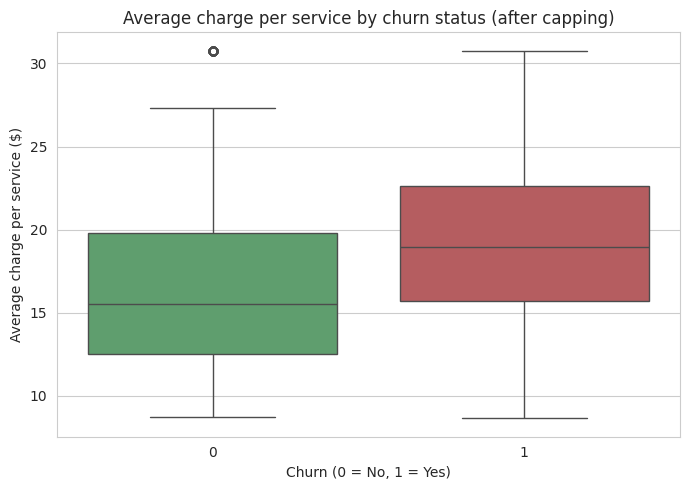

In [14]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x='Churn', y='AvgChargePerService', hue='Churn', palette=['#55A868', '#C44E52'], legend=False)
plt.title('Average charge per service by churn status (after capping)')
plt.xlabel('Churn (0 = No, 1 = Yes)')
plt.ylabel('Average charge per service ($)')
plt.tight_layout()
plt.show()

**Feature selection** using three complementary methods: correlation with the target,
a variance threshold check, and Random Forest feature importance.

In [15]:
corr_with_churn = df.corr(numeric_only=True)['Churn'].drop('Churn').sort_values(key=abs, ascending=False)
print('Top 10 correlations with Churn:')
corr_with_churn.head(10).round(3)

Top 10 correlations with Churn:


Contract                         -0.397
tenure                           -0.352
InternetService_Fiber optic       0.308
PaymentMethod_Electronic check    0.302
AvgChargePerService               0.296
InternetService_No               -0.228
TotalCharges                     -0.198
MonthlyCharges                    0.193
PaperlessBilling                  0.192
OnlineSecurity_Yes               -0.171
Name: Churn, dtype: float64

In [16]:
X = df.drop(columns=['Churn'])
vt = VarianceThreshold(threshold=0.01)
vt.fit(X)
low_var_cols = X.columns[~vt.get_support()].tolist()
print('Near-zero-variance columns (<0.01):', low_var_cols if low_var_cols else 'None found')

Near-zero-variance columns (<0.01): None found


In [17]:
rf = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42)
rf.fit(X, df['Churn'])
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print('Top 10 features by Random Forest importance:')
importances.head(10).round(3)

Top 10 features by Random Forest importance:


tenure                            0.164
Contract                          0.163
TotalCharges                      0.102
MonthlyCharges                    0.100
AvgChargePerService               0.087
InternetService_Fiber optic       0.080
TenureGroup                       0.061
PaymentMethod_Electronic check    0.055
InternetService_No                0.031
NumServicesSubscribed             0.024
dtype: float64

**Conclusion (feature selection):** `Contract`, `tenure`, `TotalCharges`, `MonthlyCharges`
and the engineered `AvgChargePerService` consistently rank at the top across both correlation
and model-based importance — this cross-validates that the engineered features carry real
predictive signal, not just noise. No columns had near-zero variance, so none are dropped on
that basis.

## Exploratory Visualizations
Six required chart types: 2 histograms, 1 box plot (above), 2 count plots, 1 scatter plot,
and 1 correlation heatmap.

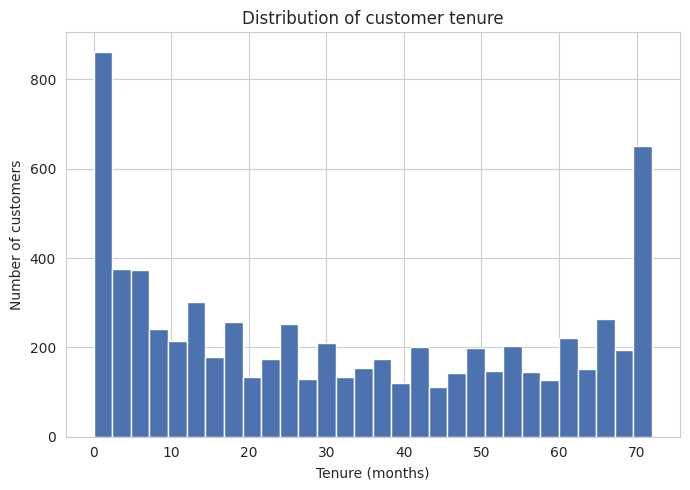

In [18]:
df_readable = pd.read_csv(DATA_PATH)
plt.figure(figsize=(7, 5))
plt.hist(df_readable['tenure'], bins=30, color='#4C72B0', edgecolor='white')
plt.title('Distribution of customer tenure')
plt.xlabel('Tenure (months)')
plt.ylabel('Number of customers')
plt.tight_layout()
plt.show()

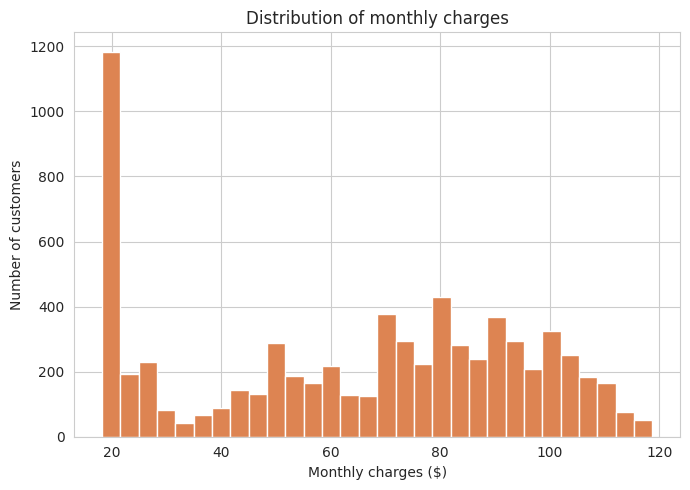

In [19]:
plt.figure(figsize=(7, 5))
plt.hist(df_readable['MonthlyCharges'], bins=30, color='#DD8452', edgecolor='white')
plt.title('Distribution of monthly charges')
plt.xlabel('Monthly charges ($)')
plt.ylabel('Number of customers')
plt.tight_layout()
plt.show()

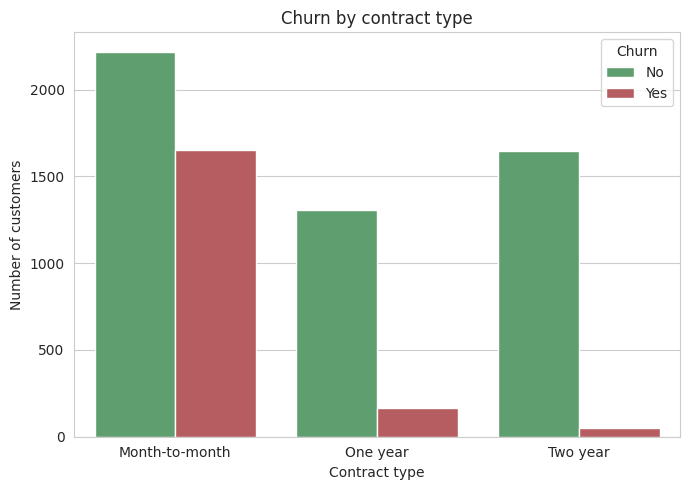

In [20]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df_readable, x='Contract', hue='Churn', palette=['#55A868', '#C44E52'])
plt.title('Churn by contract type')
plt.xlabel('Contract type')
plt.ylabel('Number of customers')
plt.legend(title='Churn')
plt.tight_layout()
plt.show()

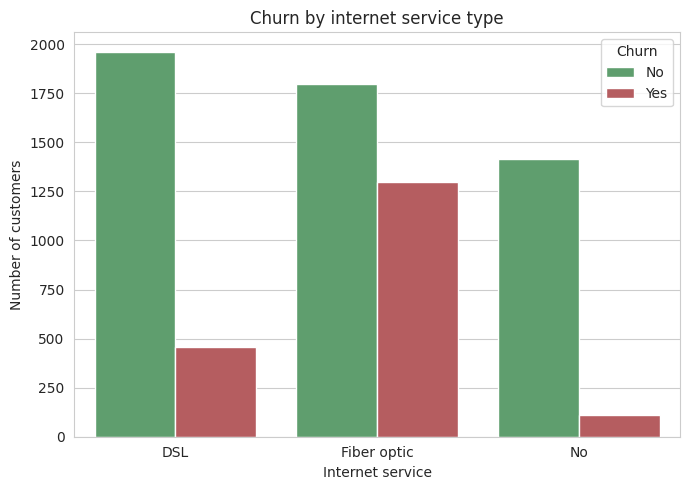

In [21]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df_readable, x='InternetService', hue='Churn', palette=['#55A868', '#C44E52'])
plt.title('Churn by internet service type')
plt.xlabel('Internet service')
plt.ylabel('Number of customers')
plt.legend(title='Churn')
plt.tight_layout()
plt.show()

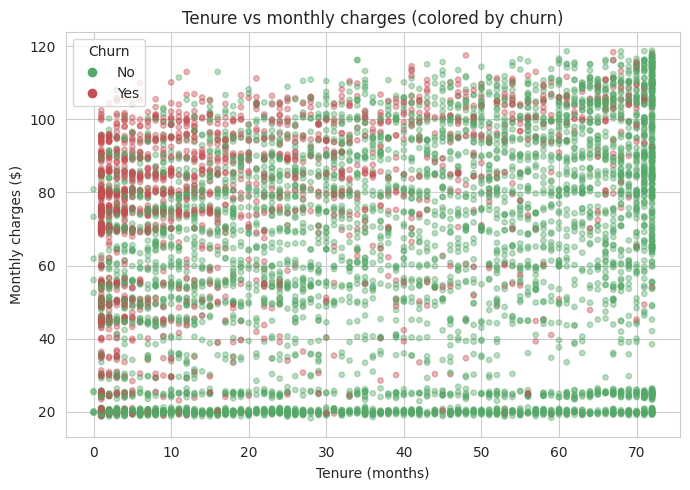

In [22]:
plt.figure(figsize=(7, 5))
colors = df_readable['Churn'].map({'Yes': '#C44E52', 'No': '#55A868'})
plt.scatter(df_readable['tenure'], df_readable['MonthlyCharges'], c=colors, alpha=0.4, s=15)
plt.title('Tenure vs monthly charges (colored by churn)')
plt.xlabel('Tenure (months)')
plt.ylabel('Monthly charges ($)')
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=c, markersize=8, label=l)
           for c, l in [('#55A868', 'No'), ('#C44E52', 'Yes')]]
plt.legend(handles=handles, title='Churn')
plt.tight_layout()
plt.show()

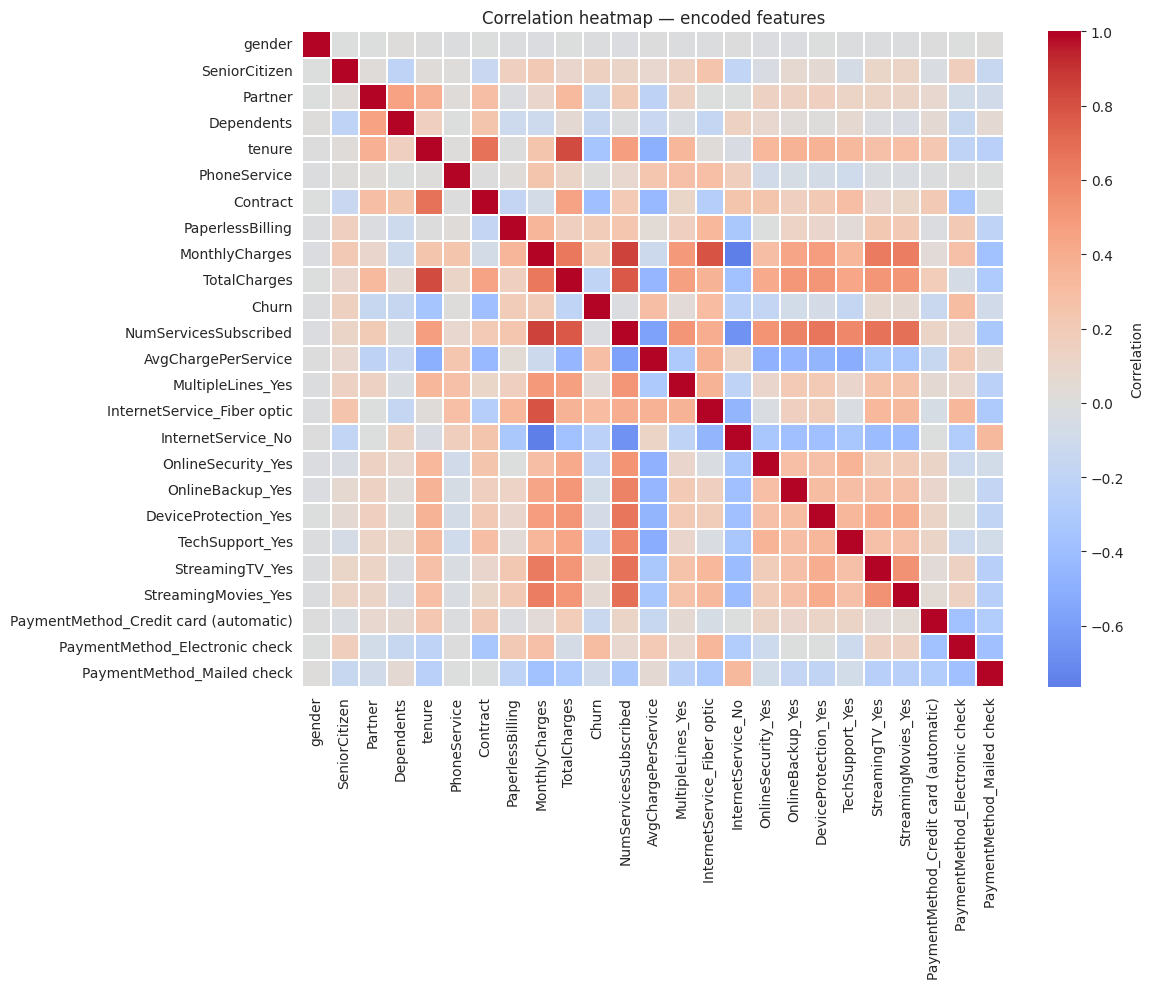

In [23]:
plt.figure(figsize=(12, 10))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, cmap='coolwarm', center=0, linewidths=0.3, cbar_kws={'label': 'Correlation'})
plt.title('Correlation heatmap — encoded features')
plt.tight_layout()
plt.show()

## Part 6 — Machine-Learning-Ready Dataset

Apply `StandardScaler` to the numeric columns (post outlier-treatment) and save the final,
fully numeric, missing-value-free dataset.

In [24]:
scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

assert df.isna().sum().sum() == 0, 'Missing values remain!'
assert (df.dtypes == 'object').sum() == 0, 'Non-numeric columns remain!'

df.to_csv('telco_ml_ready.csv', index=False)
print('Final ML-ready dataset saved:', df.shape)
df.head()

Final ML-ready dataset saved: (7043, 26)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,Contract,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,TenureGroup,NumServicesSubscribed,AvgChargePerService,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_Yes,OnlineBackup_Yes,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,-1.277445,0,0,1,-1.160323,-0.992611,0,0,-0.928083,-0.448825,0,0,0,0,1,0,0,0,0,0,1,0
1,1,0,0,0,0.066327,1,1,0,-0.259629,-0.172165,0,2,-0.063239,-0.587881,0,0,0,1,0,1,0,0,0,0,0,1
2,1,0,0,0,-1.236724,1,0,1,-0.362660,-0.958066,1,0,-0.063239,-0.744635,0,0,0,1,1,0,0,0,0,0,0,1
3,1,0,0,0,0.514251,0,1,0,-0.746535,-0.193672,0,2,-0.063239,-1.328671,0,0,0,1,0,1,1,0,0,0,0,0
4,0,0,0,0,-1.236724,1,0,1,0.197365,-0.938874,1,0,-0.928083,2.755029,0,1,0,0,0,0,0,0,0,0,1,0


## Summary of Preprocessing Steps

1. **Data quality issues found:** `TotalCharges` mistyped as text with 11 hidden missing values
   (masked as blank strings, all for `tenure = 0` customers); no duplicate rows; three groups of
   redundant categorical labels (`"No internet/phone service"`).
2. **Cleaning:** converted `TotalCharges` to numeric and imputed the 11 blanks with 0; standardized
   redundant category labels to `"No"`.
3. **Feature engineering:** created `TenureGroup`, `NumServicesSubscribed`, `AvgChargePerService`;
   dropped `customerID`.
4. **Encoding:** Label Encoding for binaries, Ordinal Encoding for `Contract`/`TenureGroup`,
   One-Hot Encoding for remaining nominal categories.
5. **Outliers:** raw numeric columns are naturally bounded (no outliers); the engineered
   `AvgChargePerService` had ~3.3% outliers, capped via IQR winsorization rather than deleted.
6. **Feature selection:** correlation analysis, variance threshold, and Random Forest importance
   all agree that `Contract`, `tenure`, billing amounts, and the engineered features are the
   strongest predictors; no low-variance columns were dropped.
7. **Scaling:** `StandardScaler` applied to all numeric columns.
8. **Result:** a fully numeric, missing-value-free, business-informed dataset — **ready for
   model training** (Business Question 7 answered: **Yes**).